## Operator Benchmarks

Each row checks forward and backward correctness against `TorchOpsBackend`, then reports forward/backward p50 latency, p95 latency, peak CUDA memory delta, and speedup versus torch.


In [4]:
from pathlib import Path
import sys

import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "minitrain").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "tests"))

from minitrain.model.ops import get_ops_backend
from operator_nsight import nsight_kernel, register_nsight_kernel
from operator_bench_utils import (
    BenchCase,
    bench_sweep,
    collect_triton_best_configs,
    display_triton_config_summary,
    plot_kernel_grid,
    to_summary_dataframe,
)

torch.manual_seed(0)
assert torch.cuda.is_available(), "operator benchmarks require CUDA"

DEVICE = torch.device("cuda")
DTYPE = torch.float16
PROVIDERS = ("torch", "triton", "cuda")
WARMUP_MS = 25
REP_MS = 100
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS = (
    "fwd_p50_ms",
    "fwd_p95_ms",
    "fwd_peak_mem_mb",
    "fwd_speedup",
    "bwd_p50_ms",
    "bwd_p95_ms",
    "bwd_peak_mem_mb",
    "bwd_speedup",
)

print(torch.__version__)
print(torch.cuda.get_device_name(0))


2.5.1+cu121
NVIDIA GeForce RTX 3050 Laptop GPU


Each kernel section now provides `make_case(size)` and `forward(provider, tensors)`. The runner owns tensor cloning, forward/backward correctness, timing, memory measurement, and cleanup. Cleanup clears the torch-created tensor dictionary before releasing the CUDA cache.

Generate a small Nsight Compute report with one line, for example `nsight_kernel("rmsnorm")` or `nsight_kernel("attention", mode="bwd")`. `size` uses the same logical size as the corresponding benchmark when explicitly provided. The default `LaunchStats` section reports launch geometry, registers, and shared memory; pass `set_name="basic"` for a broader, slower analysis. Autotuned kernels are tuned once before ncu starts, then the worker is pinned to the winning configuration.

In [5]:
def register_kernel(
    kernel,
    sizes,
    size_label,
    make_case,
    forward,
    *,
    nsight_size=None,
    nsight_autotune_kernels=None,
):
    sizes = tuple(sizes)
    register_nsight_kernel(
        kernel,
        make_case,
        forward,
        default_size=min(sizes) if nsight_size is None else nsight_size,
        autotune_kernels=nsight_autotune_kernels,
    )
    return sizes


def run_kernel(
    kernel,
    sizes,
    size_label,
    make_case,
    forward,
    *,
    autotune_kernels=None,
    nsight_size=None,
    nsight_autotune_kernels=None,
):
    sizes = register_kernel(
        kernel,
        sizes,
        size_label,
        make_case,
        forward,
        nsight_size=nsight_size,
        nsight_autotune_kernels=nsight_autotune_kernels,
    )
    rows = bench_sweep(
        kernel=kernel,
        providers=PROVIDERS,
        sizes=sizes,
        size_label=size_label,
        make_case=make_case,
        forward=forward,
        warmup_ms=WARMUP_MS,
        rep_ms=REP_MS,
        autotune_kernels=autotune_kernels,
    )
    display(to_summary_dataframe(rows))
    plot_kernel_grid(rows, metrics=METRICS, save_path=FIG_DIR / f"{kernel}_summary.png")
    return rows


## RMSNorm

Sweep parameter: `rows`.

X-axis: activation tensor elements, `rows * hidden`.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,rmsnorm,torch,16384,ok,True,True,0.000000,0.000000,0.033792,0.034816,0.125000,1.000000,0.601696,1.178685,0.250000,1.000000
1,rmsnorm,triton,16384,ok,True,True,0.001953,0.015625,0.006144,0.006144,0.031738,5.500000,0.342048,0.449280,0.080078,1.759098
2,rmsnorm,torch,32768,ok,True,True,0.000000,0.000000,0.027648,0.029696,0.250000,1.000000,0.592896,1.148366,0.500000,1.000000
3,rmsnorm,triton,32768,ok,True,True,0.001953,0.015625,0.005120,0.006144,0.062988,5.400000,0.376368,0.509910,0.142578,1.575309
4,rmsnorm,torch,65536,ok,True,True,0.000000,0.000000,0.028672,0.030720,0.500000,1.000000,0.541584,1.111806,0.999512,1.000000
5,rmsnorm,triton,65536,ok,True,True,0.003906,0.031250,0.007168,0.008192,0.125977,4.000000,0.410000,0.644198,0.267578,1.320937
6,rmsnorm,torch,131072,ok,True,True,0.000000,0.000000,0.035840,0.037888,1.000000,1.000000,0.535056,1.071229,1.998047,1.000000
7,rmsnorm,triton,131072,ok,True,True,0.003906,0.031250,0.008192,0.009216,0.251953,4.375000,0.351744,0.446720,0.517578,1.521152
8,rmsnorm,torch,262144,ok,True,True,0.000000,0.000000,0.052224,0.054272,2.000000,1.000000,0.573440,0.982923,3.995117,1.000000
9,rmsnorm,triton,262144,ok,True,True,0.001953,0.062500,0.011264,0.011264,0.503906,4.636364,0.397440,0.644352,1.017578,1.442834


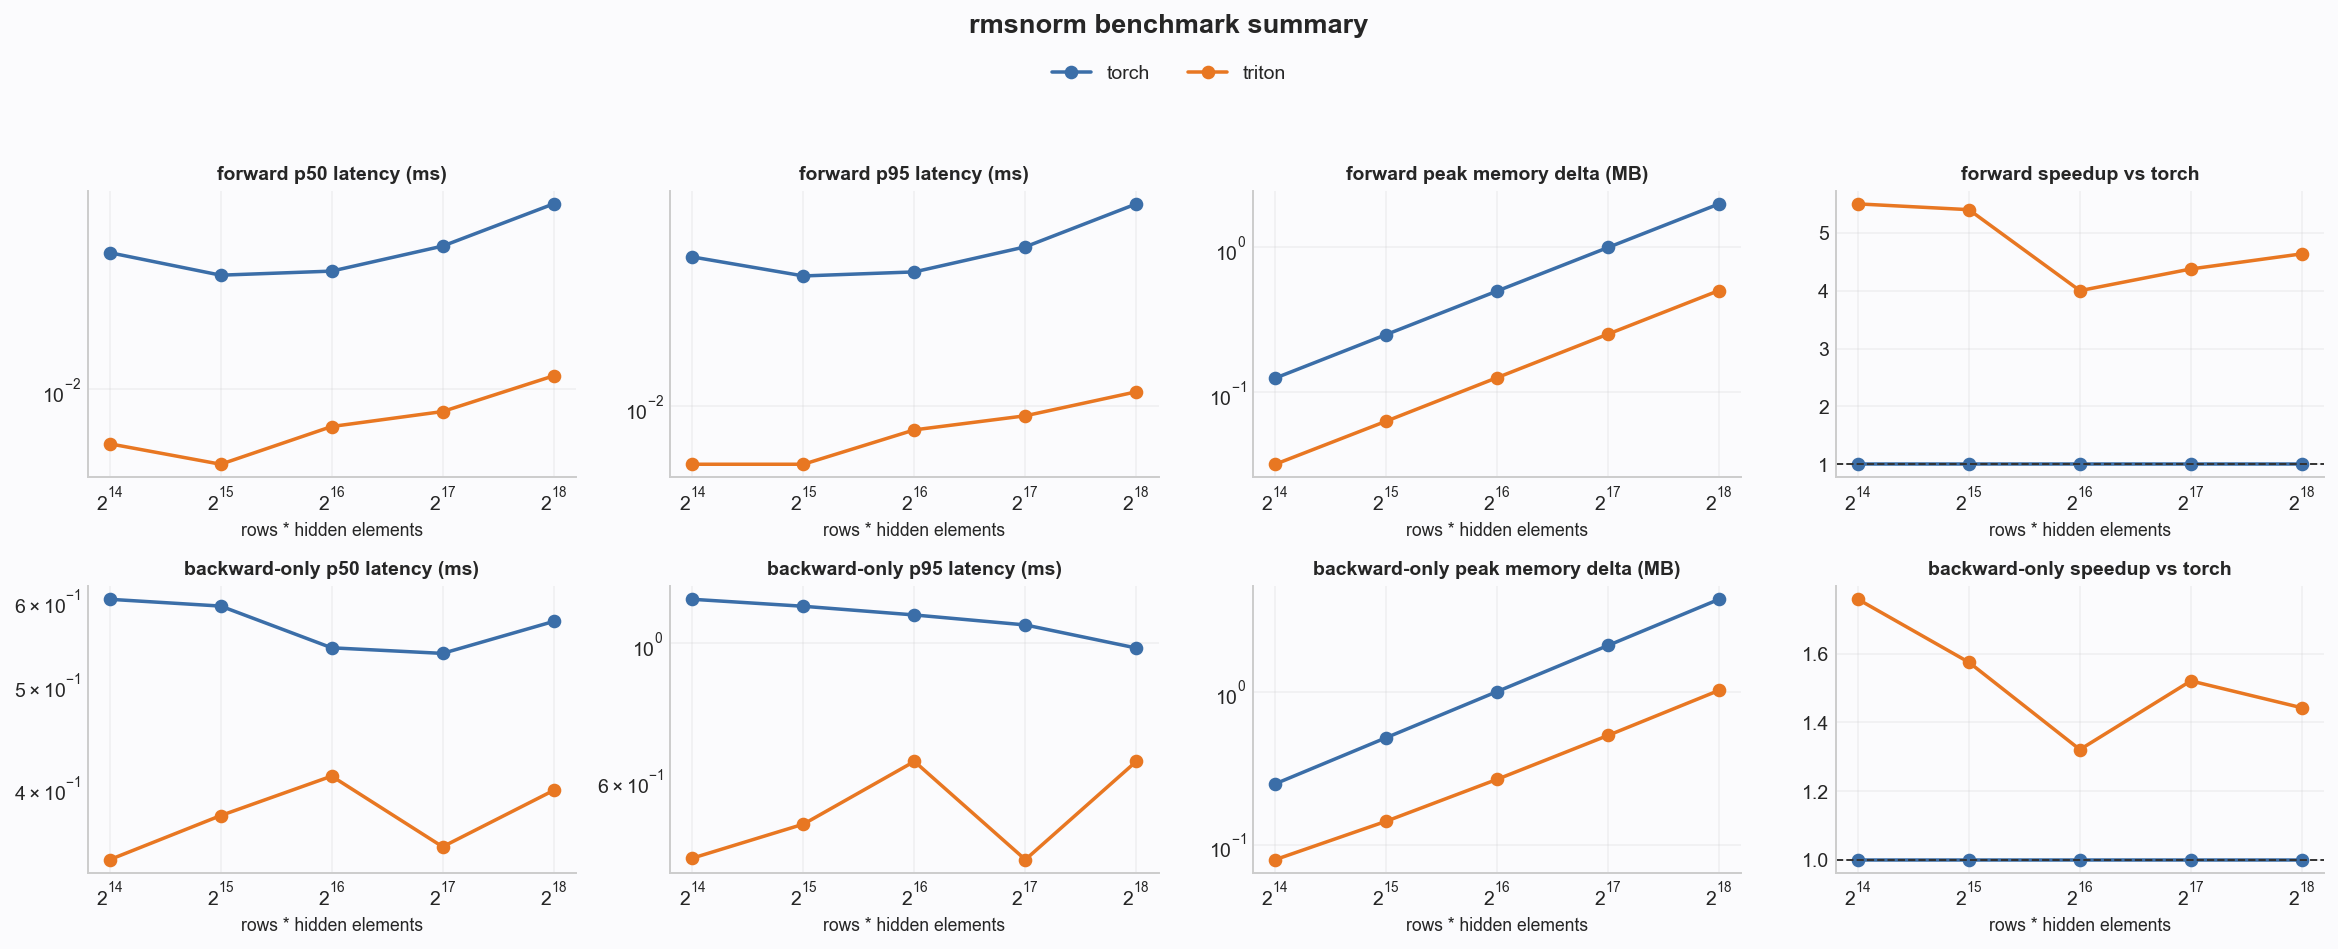

In [3]:
PROVIDERS = ("torch", "triton")
def make_rmsnorm_case(size):
    hidden = 256
    rows = size // hidden
    return BenchCase(
        tensors={
            "x": torch.randn(rows, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.ones(hidden, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("x", "weight"),
    )


def rmsnorm_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rmsnorm(tensors["x"], tensors["weight"], 1e-5)


rmsnorm_sizes = [256 * rows for rows in (64, 128, 256, 512, 1024)]
rmsnorm_rows = run_kernel(
    "rmsnorm",
    rmsnorm_sizes,
    "rows * hidden elements",
    make_rmsnorm_case,
    rmsnorm_forward,
)

## RoPE

Sweep parameter: `seq`.

X-axis: Q+K tensor elements, `2 * batch * heads * seq * head_dim`.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,rope,torch,16384,ok,True,True,0.000000,0.0,0.096320,0.156544,0.06250,1.000000,0.701968,1.071720,0.078613,1.000000
1,rope,triton,16384,ok,True,True,0.001953,0.0,0.005120,0.006144,0.03125,18.812501,0.406464,0.475443,0.062988,1.727011
2,rope,torch,32768,ok,True,True,0.000000,0.0,0.109568,0.158720,0.12500,1.000000,0.628736,0.975104,0.156738,1.000000
3,rope,triton,32768,ok,True,True,0.001953,0.0,0.006144,0.008090,0.06250,17.833333,0.431568,0.523878,0.125488,1.456864
4,rope,torch,65536,ok,True,True,0.000000,0.0,0.094208,0.126464,0.25000,1.000000,0.581680,0.622694,0.312988,1.000000
5,rope,triton,65536,ok,True,True,0.001953,0.0,0.006144,0.007168,0.12500,15.333333,0.349696,0.378880,0.250488,1.663388
6,rope,torch,131072,ok,True,True,0.000000,0.0,0.089088,0.129024,0.50000,1.000000,0.581184,0.669850,0.625488,1.000000
7,rope,triton,131072,ok,True,True,0.003906,0.0,0.008192,0.009216,0.25000,10.875000,0.348672,0.387226,0.500488,1.666850
8,rope,torch,262144,ok,True,True,0.000000,0.0,0.086528,0.130390,1.00000,1.000000,0.588240,0.777472,1.250488,1.000000
9,rope,triton,262144,ok,True,True,0.001953,0.0,0.011264,0.012288,0.50000,7.681818,0.354304,0.488642,1.000488,1.660269


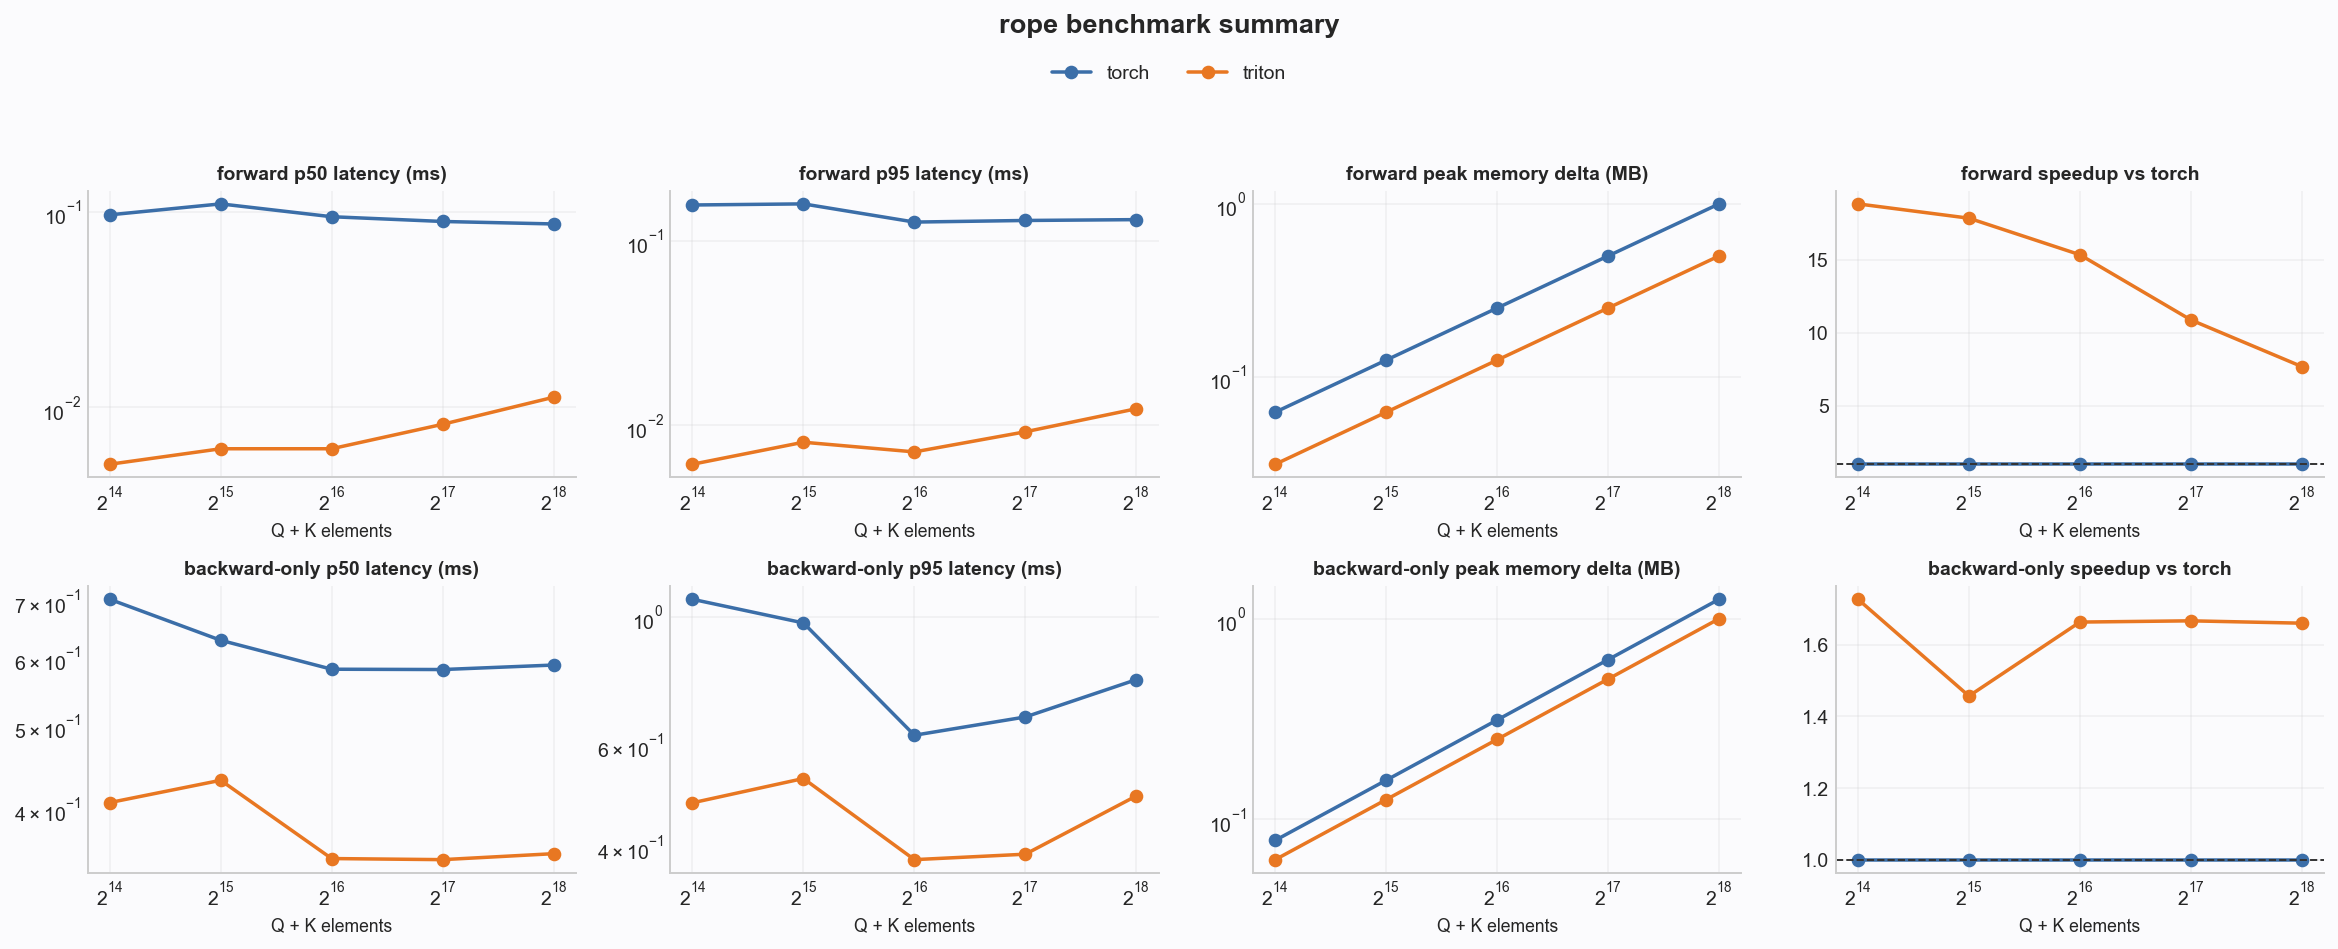

In [4]:
PROVIDERS = ("torch", "triton")
def rope_cache(seq, dim):
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2, device=DEVICE).float() / dim))
    freqs = torch.outer(torch.arange(seq, device=DEVICE).float(), inv_freq)
    emb = torch.cat((freqs, freqs), dim=-1)
    return emb.cos().to(dtype=DTYPE), emb.sin().to(dtype=DTYPE)


def make_rope_case(size):
    batch, heads, head_dim = 1, 4, 64
    seq = size // (2 * batch * heads * head_dim)
    cos, sin = rope_cache(seq, head_dim)
    return BenchCase(
        tensors={
            "q": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "k": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "cos": cos,
            "sin": sin,
        },
        grad_names=("q", "k"),
    )


def rope_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rope(tensors["q"], tensors["k"], tensors["cos"], tensors["sin"])


rope_sizes = [2 * 1 * 4 * seq * 64 for seq in (32, 64, 128, 256, 512)]
rope_rows = run_kernel("rope", rope_sizes, "Q + K elements", make_rope_case, rope_forward)


## SwiGLU

Sweep parameter: `rows`.

X-axis: input tensor elements, `2 * rows * intermediate` for gate and up.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,swiglu,torch,65536,ok,True,True,0.000000,0.000000,0.010240,0.011264,0.1250,1.000000,0.222800,0.292301,0.187988,1.000000
1,swiglu,triton,65536,ok,True,True,0.000000,0.000977,0.006144,0.007168,0.0625,1.666667,0.321024,0.350232,0.187988,0.694029
2,swiglu,torch,131072,ok,True,True,0.000000,0.000000,0.010240,0.011264,0.2500,1.000000,0.236608,0.272538,0.375488,1.000000
3,swiglu,triton,131072,ok,True,True,0.000244,0.000488,0.007168,0.007894,0.1250,1.428571,0.278048,0.337050,0.375488,0.850961
4,swiglu,torch,262144,ok,True,True,0.000000,0.000000,0.012304,0.014336,0.5000,1.000000,0.212464,0.247245,0.750488,1.000000
5,swiglu,triton,262144,ok,True,True,0.000122,0.000488,0.009216,0.009230,0.2500,1.335069,0.407552,0.703747,0.750488,0.521318
6,swiglu,torch,524288,ok,True,True,0.000000,0.000000,0.018432,0.019456,1.0000,1.000000,0.234496,0.291891,1.500488,1.000000
7,swiglu,triton,524288,ok,True,True,0.000244,0.001953,0.013312,0.014336,0.5000,1.384615,0.303616,0.375296,1.500488,0.772344
8,swiglu,torch,1048576,ok,True,True,0.000000,0.000000,0.033792,0.035840,2.0000,1.000000,0.209376,0.279597,3.000488,1.000000
9,swiglu,triton,1048576,ok,True,True,0.000244,0.000977,0.022528,0.022960,1.0000,1.500000,0.257552,0.351840,3.000488,0.812946


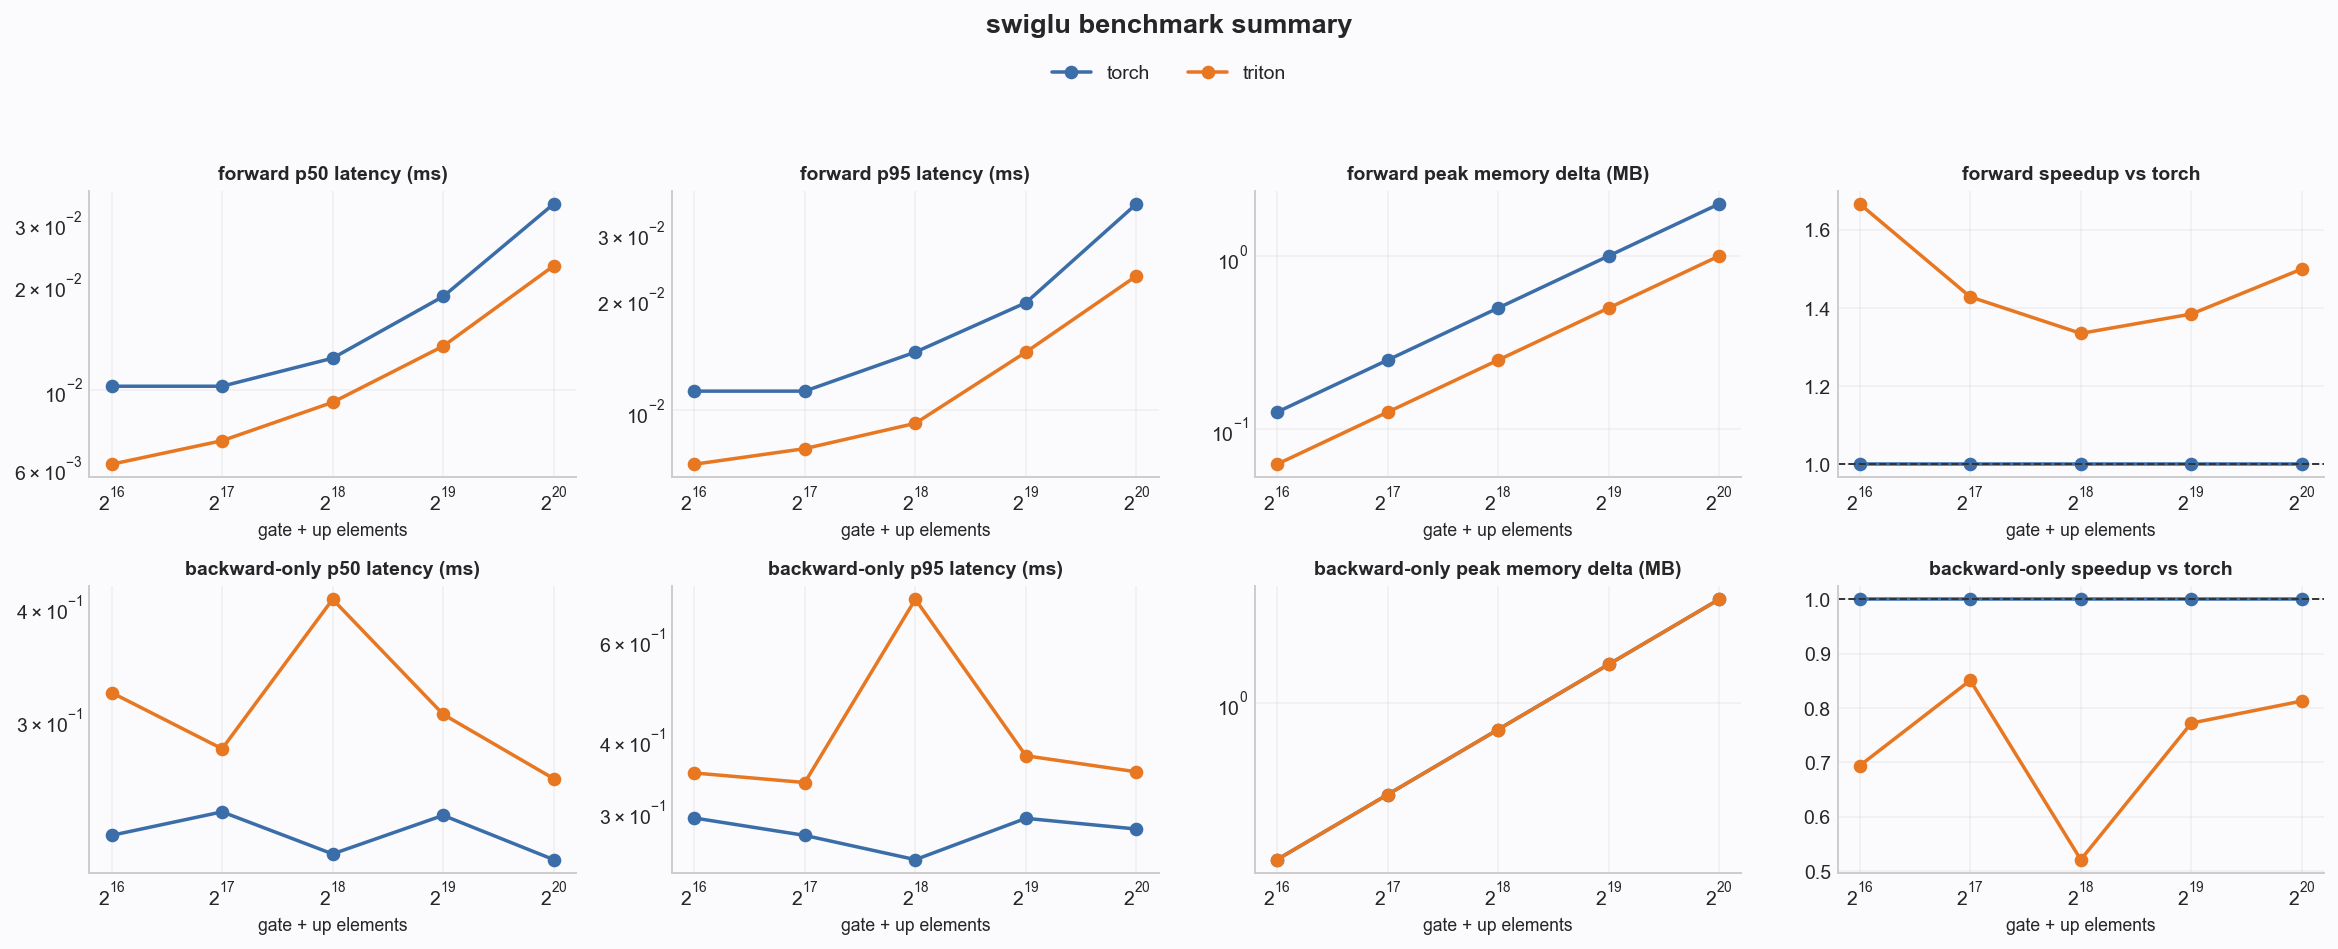

In [6]:
PROVIDERS = ("torch", "triton")
def make_swiglu_case(size):
    intermediate = 512
    rows = size // (2 * intermediate)
    return BenchCase(
        tensors={
            "gate": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
            "up": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("gate", "up"),
    )


def swiglu_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.swiglu(tensors["gate"], tensors["up"])


swiglu_sizes = [2 * rows * 512 for rows in (64, 128, 256, 512, 1024)]
swiglu_rows = run_kernel(
    "swiglu",
    swiglu_sizes,
    "gate + up elements",
    make_swiglu_case,
    swiglu_forward,
)


## CrossEntropy

Sweep parameter: `tokens`.

X-axis: logits tensor elements, `tokens * vocab`.

In [ ]:
def make_cross_entropy_case(size):
    vocab = 1024
    tokens = size // vocab
    return BenchCase(
        tensors={
            "logits": torch.randn(tokens, vocab, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("logits",),
    )


def cross_entropy_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.cross_entropy(tensors["logits"], tensors["targets"])


cross_entropy_sizes = [tokens * 1024 for tokens in (64, 128, 256, 512, 1024)]
cross_entropy_rows = run_kernel(
    "cross_entropy",
    cross_entropy_sizes,
    "tokens * vocab logits elements",
    make_cross_entropy_case,
    cross_entropy_forward,
)


## FusedLinearCrossEntropy

Sweep parameter: `vocab`.

X-axis: logical logits elements, `tokens * vocab`. This is the tensor a fused implementation tries not to materialize.

In [ ]:
def make_fused_linear_ce_case(size):
    tokens, hidden = 128, 256
    vocab = size // tokens
    return BenchCase(
        tensors={
            "x": torch.randn(tokens, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.randn(vocab, hidden, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("x", "weight"),
    )


def fused_linear_ce_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.fused_linear_cross_entropy(tensors["x"], tensors["weight"], tensors["targets"])


fused_linear_ce_sizes = [128 * vocab for vocab in (512, 1024, 2048, 4096, 8192)]
fused_linear_ce_rows = run_kernel(
    "fused_linear_cross_entropy",
    fused_linear_ce_sizes,
    "tokens * vocab logical logits elements",
    make_fused_linear_ce_case,
    fused_linear_ce_forward,
)


## FlashAttention

### FlashAttention (no dropout)

Bench MiniTrain's attention path and print the PyTorch SDPA backend selected for the same benchmark shapes.


In [ ]:
import math

import pandas as pd
import torch.nn.functional as F
from torch.profiler import ProfilerActivity

from minitrain.kernels.cuda_ext.build import get_build_config as get_cuda_build_config
from minitrain.kernels.cuda_ext.flash_attention import (
    flash_attention_dropout_mask_for_testing as cuda_flash_attention_dropout_mask,
    is_flash_attention_supported as is_cuda_flash_attention_supported,
)
from minitrain.kernels.triton.flash_attention import (
    flash_attention_autotune_kernels,
    flash_attention_backward,
    flash_attention_dropout_mask,
    flash_attention_forward,
    is_flash_attention_supported,
)
from operator_bench_utils import benchmark_step, release_cache

PROVIDERS = ("torch", "triton", "cuda")
print("CUDA FlashAttention build:", get_cuda_build_config())

ATTENTION_BATCH = 2
ATTENTION_HEADS = 4
ATTENTION_HEAD_DIM = 128
ATTENTION_SEQS = (1024, 4 * 1024, 16 * 1024, 64 * 1024)
ATTENTION_IS_CAUSAL = True

SDPA_ATEN_BACKENDS = (
    ("aten::_scaled_dot_product_flash_attention", "flash_attention"),
    ("aten::_scaled_dot_product_efficient_attention", "memory_efficient_attention"),
    ("aten::_scaled_dot_product_cudnn_attention", "cudnn_attention"),
    ("aten::_scaled_dot_product_attention_math", "math"),
)


def attention_size(seq):
    return 3 * ATTENTION_BATCH * ATTENTION_HEADS * seq * ATTENTION_HEAD_DIM


def make_attention_case(size):
    seq = size // (3 * ATTENTION_BATCH * ATTENTION_HEADS * ATTENTION_HEAD_DIM)
    shape = (ATTENTION_BATCH, ATTENTION_HEADS, seq, ATTENTION_HEAD_DIM)
    return BenchCase(
        tensors={name: torch.randn(shape, device=DEVICE, dtype=DTYPE) for name in ("q", "k", "v")},
        grad_names=("q", "k", "v"),
    )


def attention_forward(provider, tensors):
    # A benchmark row named CUDA must execute the native extension. Production
    # keeps capability fallback, but benchmark data must never time that fallback.
    if provider == "cuda" and not is_cuda_flash_attention_supported(
        tensors["q"], tensors["k"], tensors["v"], dropout_p=0.0
    ):
        raise RuntimeError(
            "active CUDA build does not contain this fp16 attention branch"
        )
    if provider == "triton" and not is_flash_attention_supported(
        tensors["q"], tensors["k"], tensors["v"], dropout_p=0.0
    ):
        raise RuntimeError("Triton does not contain this attention branch")
    return get_ops_backend(provider).attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=ATTENTION_IS_CAUSAL,
        dropout_p=0.0,
    )


def detect_pytorch_sdpa_backend(q, k, v, *, dropout_p):
    activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    torch.cuda.synchronize()
    with torch.profiler.profile(activities=activities) as profiler:
        with torch.no_grad():
            F.scaled_dot_product_attention(
                q, k, v, is_causal=ATTENTION_IS_CAUSAL, dropout_p=dropout_p
            )
        torch.cuda.synchronize()

    event_keys = {event.key for event in profiler.key_averages()}
    for aten_name, backend_name in SDPA_ATEN_BACKENDS:
        if aten_name in event_keys:
            return backend_name
    events = sorted(key for key in event_keys if "scaled_dot_product" in key or "sdp" in key.lower())
    return "unknown: " + ", ".join(events[:6])


def print_sdpa_backend_report(sizes, make_case, *, dropout_p):
    print(f"PyTorch SDPA backend selection (causal={ATTENTION_IS_CAUSAL}, dropout_p={dropout_p}):")
    for size in sizes:
        case = make_case(size)
        try:
            q, k, v = (case.tensors[name] for name in ("q", "k", "v"))
            backend = detect_pytorch_sdpa_backend(q, k, v, dropout_p=dropout_p)
            print(f"  shape={tuple(q.shape)} -> {backend}")
        finally:
            case.tensors.clear()
            release_cache()


attention_sizes = [attention_size(seq) for seq in ATTENTION_SEQS]
print_sdpa_backend_report(attention_sizes, make_attention_case, dropout_p=0.0)
attention_rows = run_kernel(
    "attention",
    attention_sizes,
    "Q + K + V elements",
    make_attention_case,
    attention_forward,
    autotune_kernels=flash_attention_autotune_kernels(),
    nsight_size=attention_size(128),
    nsight_autotune_kernels=flash_attention_autotune_kernels,
)

attention_summary = to_summary_dataframe(attention_rows)
attention_failures = attention_summary[attention_summary["status"] != "ok"]
if len(attention_failures):
    display(attention_failures[["provider", "size", "status", "error"]])


CUDA FlashAttention build: CudaBuildConfig(profile='workstation', archs=('86',), head_dims=(32, 64, 128), dtypes=('fp16', 'bf16'))
PyTorch SDPA backend selection (causal=True, dropout_p=0.0):
  shape=(2, 4, 1024, 128) -> memory_efficient_attention
  shape=(2, 4, 4096, 128) -> memory_efficient_attention
  shape=(2, 4, 16384, 128) -> memory_efficient_attention
  shape=(2, 4, 65536, 128) -> memory_efficient_attention


### FlashAttention（dropout 与 CUDA fp16 全矩阵）

Correctness 使用 CUDA kernel 导出的 Philox keep mask 构造 fp32 参考；性能部分比较 Torch、Triton 和 CUDA。


,dtype,head_dim,causal,dropout_p,rng_behavior_correct,debug_output_equal,keep_ratio,status,fwd_max_abs,fwd_correct,dq_max_abs,dq_correct,dk_max_abs,dk_correct,dv_max_abs,dv_correct,expanded_dout_correct,all_correct
0,fp16,32,False,0.00,True,True,1.000000,ok,0.000400,True,0.000559,True,0.000474,True,0.000720,True,True,True
1,fp16,32,False,0.25,True,True,0.735573,ok,0.000484,True,0.000745,True,0.000441,True,0.000627,True,True,True
2,fp16,32,True,0.00,True,True,1.000000,ok,0.000609,True,0.000909,True,0.000990,True,0.000941,True,True,True
3,fp16,32,True,0.25,True,True,0.751278,ok,0.000985,True,0.000945,True,0.001518,True,0.001995,True,True,True
4,fp16,40,False,0.00,True,True,1.000000,ok,0.000340,True,0.000319,True,0.000428,True,0.000630,True,True,True
5,fp16,40,False,0.25,True,True,0.747626,ok,0.000345,True,0.000432,True,0.000491,True,0.000721,True,True,True
6,fp16,40,True,0.00,True,True,1.000000,ok,0.000750,True,0.001656,True,0.000956,True,0.000920,True,True,True
7,fp16,40,True,0.25,True,True,0.752009,ok,0.000845,True,0.001017,True,0.001103,True,0.001358,True,True,True
8,fp16,64,False,0.00,True,True,1.000000,ok,0.000464,True,0.000901,True,0.000695,True,0.000537,True,True,True
9,fp16,64,False,0.25,True,True,0.763696,ok,0.000421,True,0.000807,True,0.000856,True,0.000446,True,True,True


,dtype,head_dim,causal,dropout_p,input_stride,outer_noncontiguous,status,stream_id,kernel_input_stride,kernel_outer_noncontiguous,output_stride,debug_output_equal,fwd_correct,dq_correct,dk_correct,dv_correct,all_correct
0,fp16,128,False,0.00,"(9472, 128, 256, 1)",True,ok,2176717001216,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True
1,fp16,128,False,0.25,"(9472, 128, 256, 1)",True,ok,2176717000480,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True
2,fp16,128,True,0.00,"(9472, 128, 256, 1)",True,ok,2176717001056,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True
3,fp16,128,True,0.25,"(9472, 128, 256, 1)",True,ok,2176717000720,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True


,case,shape,last_stride,dropout_p,supported,expected,correct
0,valid_d128,"(1, 2, 7, 128)",1,0.000000e+00,True,True,True
1,empty_batch,"(0, 2, 7, 128)",1,0.000000e+00,False,False,True
2,empty_heads,"(1, 0, 7, 128)",1,0.000000e+00,False,False,True
3,empty_sequence,"(1, 2, 0, 128)",1,0.000000e+00,False,False,True
4,fp32_dtype,"(1, 2, 7, 128)",1,0.000000e+00,False,False,True
5,head_dim_not_multiple_of_8,"(1, 2, 7, 130)",1,0.000000e+00,False,False,True
6,head_dim_over_256,"(1, 2, 7, 264)",1,0.000000e+00,False,False,True
7,dropout_out_of_range,"(1, 2, 7, 128)",1,1.000000e+00,False,False,True
8,dropout_rounds_to_float32_one,"(1, 2, 7, 128)",1,1.000000e+00,False,False,True
9,dropout_underflows_to_float32_zero,"(1, 2, 7, 128)",1,1.000000e-50,True,True,True


CUDA fp16 correctness: 24 supported, 16 unsupported, 0 failed


,status,dropout_p,keep_ratio
0,ok,0.25,0.749268


,check,correct,max_abs
0,fwd,True,0.003206
1,dq,True,0.003723
2,dk,True,0.004937
3,dv,True,0.003134


PyTorch SDPA backend selection (causal=True, dropout_p=0.25):
  shape=(2, 4, 1024, 128) -> memory_efficient_attention
  shape=(2, 4, 4096, 128) -> memory_efficient_attention
  shape=(2, 4, 16384, 128) -> memory_efficient_attention
  shape=(2, 4, 65536, 128) -> memory_efficient_attention


,benchmark,provider,size,size_label,triton_kernel,BLOCK_M,BLOCK_N,num_warps,num_stages,num_ctas
0,attention_dropout,triton,3145728,Q + K + V elements,flash_attention_forward,64,32,4,2,1
1,attention_dropout,triton,3145728,Q + K + V elements,flash_attention_backward,128,128,8,1,1
2,attention_dropout,triton,12582912,Q + K + V elements,flash_attention_forward,64,32,4,2,1
3,attention_dropout,triton,12582912,Q + K + V elements,flash_attention_backward,128,128,8,1,1
4,attention_dropout,triton,50331648,Q + K + V elements,flash_attention_forward,128,32,8,3,1
5,attention_dropout,triton,50331648,Q + K + V elements,flash_attention_backward,128,128,8,1,1
6,attention_dropout,triton,201326592,Q + K + V elements,flash_attention_forward,128,32,8,3,1
7,attention_dropout,triton,201326592,Q + K + V elements,flash_attention_backward,128,128,8,1,1


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,attention_dropout,torch,3145728,ok,True,True,0.392192,0.393216,2.000000,1.000000,2.197968,2.832786,22.035645,1.000000
1,attention_dropout,triton,3145728,ok,True,True,0.343040,0.387174,2.031738,1.143284,1.316848,1.384550,8.031738,1.669113
2,attention_dropout,cuda,3145728,ok,True,True,0.248832,0.273357,2.031738,1.576132,0.670208,0.987187,12.031738,3.279531
3,attention_dropout,torch,12582912,ok,True,True,5.083136,5.655040,8.000000,1.000000,26.863104,27.200461,68.641113,1.000000
4,attention_dropout,triton,12582912,ok,True,True,4.182016,4.711219,8.125488,1.215475,14.207024,15.201634,32.125488,1.890833
5,attention_dropout,cuda,12582912,ok,True,True,2.681344,3.423130,8.125488,1.895742,6.622720,7.335259,48.125488,4.056204
6,attention_dropout,torch,50331648,ok,True,True,80.898048,80.898048,32.000000,1.000000,451.705338,457.821704,237.062988,1.000000
7,attention_dropout,triton,50331648,ok,True,True,65.650688,65.650688,32.500488,1.232250,215.225342,215.811333,128.500488,2.098755
8,attention_dropout,cuda,50331648,ok,True,True,40.048126,40.407089,32.500488,2.020021,99.664928,100.066448,192.500488,4.532240
9,attention_dropout,torch,201326592,ok,True,True,1297.888306,1297.888306,128.000000,1.000000,7248.246338,7303.592798,910.750488,1.000000


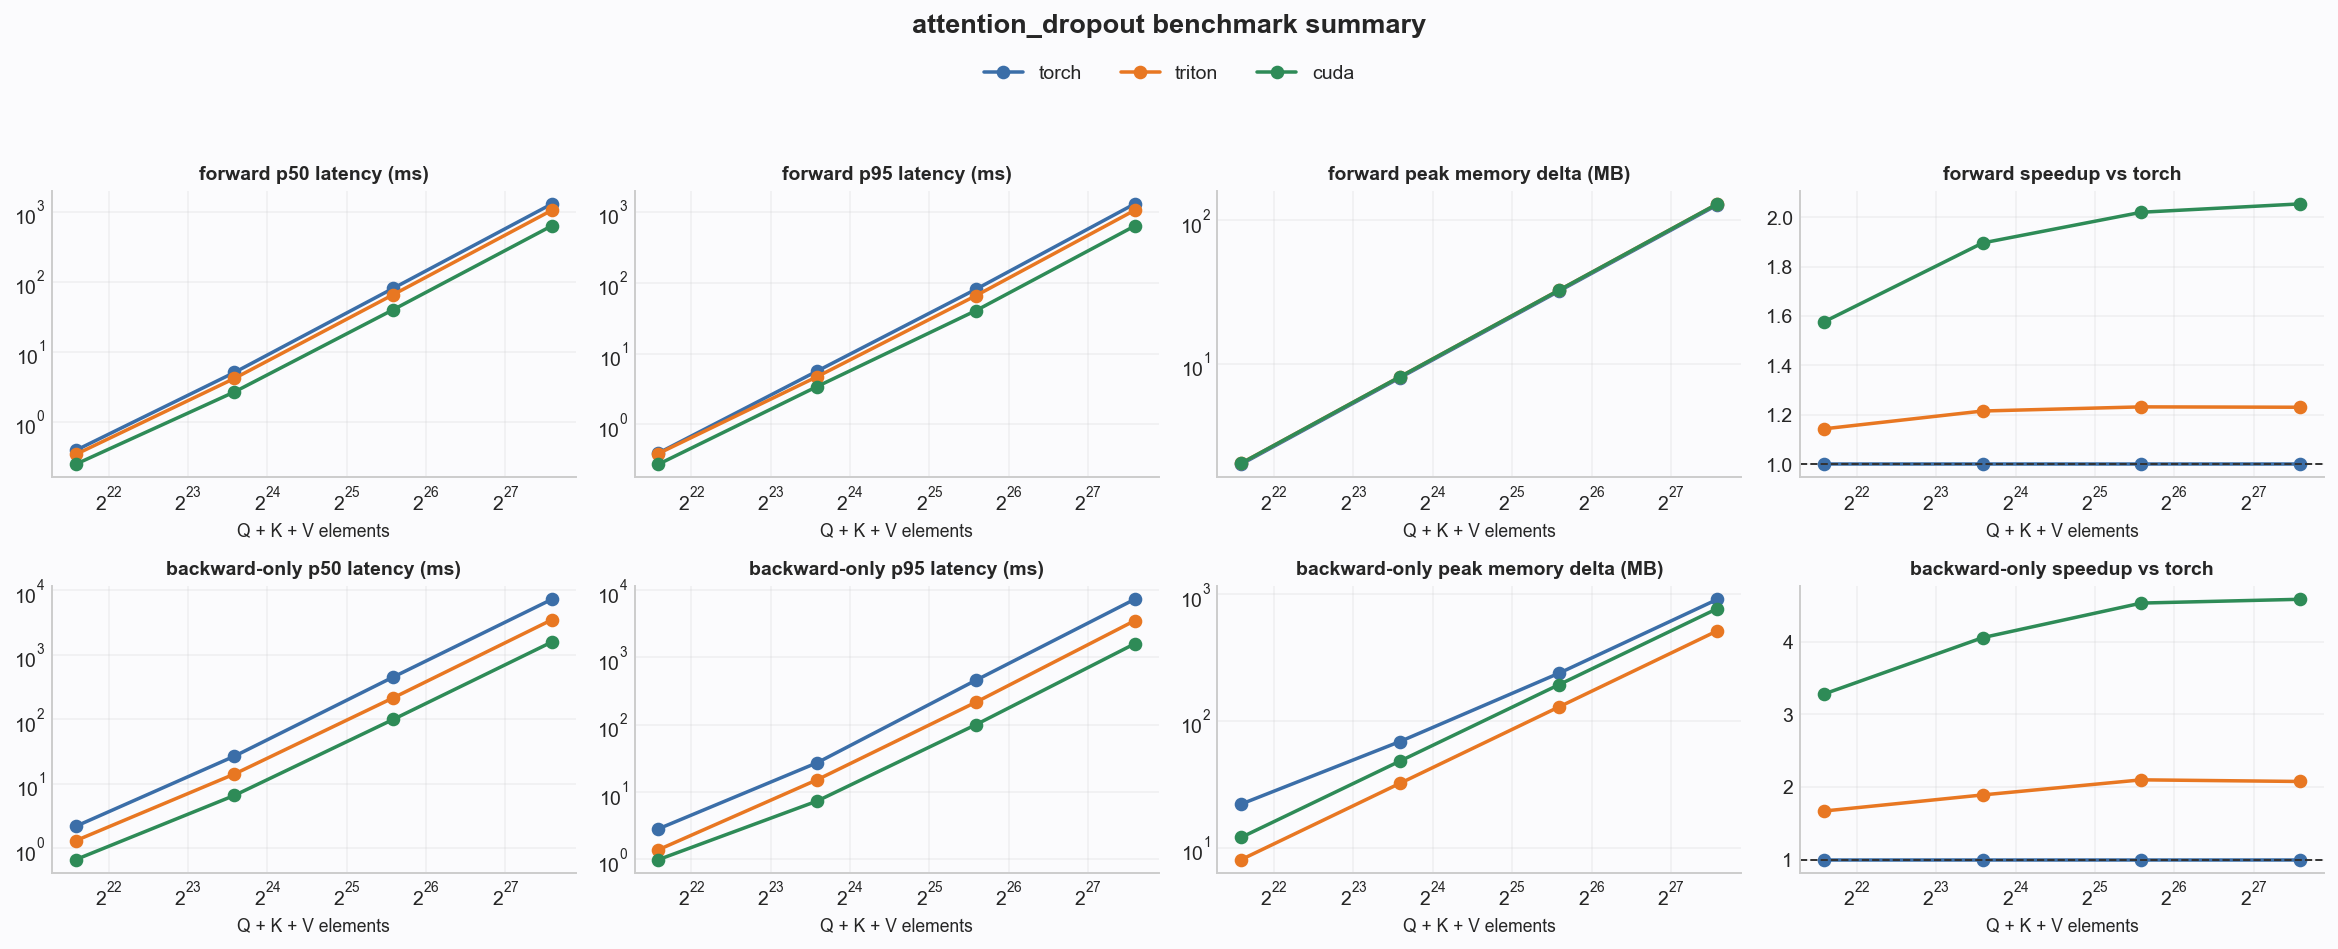

In [11]:
ATTENTION_DROPOUT_P = 0.25


def make_attention_dropout_case(size):
    return make_attention_case(size)


def attention_dropout_forward(provider, tensors):
    # Keep benchmark provider labels honest; unsupported CUDA calls are allowed
    # to fall back during training, but must not be measured as CUDA here.
    if provider == "cuda" and not is_cuda_flash_attention_supported(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        dropout_p=ATTENTION_DROPOUT_P,
    ):
        raise RuntimeError(
            "active CUDA build does not contain this fp16 dropout branch"
        )
    if provider == "triton" and not is_flash_attention_supported(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        dropout_p=ATTENTION_DROPOUT_P,
    ):
        raise RuntimeError("Triton does not contain this dropout branch")
    return get_ops_backend(provider).attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=ATTENTION_IS_CAUSAL,
        dropout_p=ATTENTION_DROPOUT_P,
    )


def attention_dropout_correctness():
    release_cache()
    try:
        batch, heads, seq, head_dim = 1, 2, 64, 32
        shape = (batch, heads, seq, head_dim)
        q, k, v = (torch.randn(shape, device=DEVICE, dtype=torch.float32) for _ in range(3))
        if not is_flash_attention_supported(q, k, v, dropout_p=ATTENTION_DROPOUT_P):
            return {"status": "unsupported"}

        seed = torch.tensor(1234567, device=DEVICE, dtype=torch.int32)
        grad_out = torch.randn_like(q)
        out, lse, _, softmax_scale = flash_attention_forward(
            q,
            k,
            v,
            is_causal=ATTENTION_IS_CAUSAL,
            dropout_p=ATTENTION_DROPOUT_P,
            dropout_seed=seed,
        )
        keep = flash_attention_dropout_mask(
            batch,
            heads,
            seq,
            seq,
            device=DEVICE,
            dropout_p=ATTENTION_DROPOUT_P,
            dropout_seed=seed,
        )

        q_ref, k_ref, v_ref = (tensor.detach().clone().requires_grad_(True) for tensor in (q, k, v))
        scores = q_ref @ k_ref.transpose(-1, -2) / math.sqrt(head_dim)
        if ATTENTION_IS_CAUSAL:
            positions = torch.arange(seq, device=DEVICE)
            scores = scores.masked_fill(positions[:, None] < positions[None, :], float("-inf"))
        probabilities = torch.softmax(scores, dim=-1)
        reference = (probabilities * keep / (1.0 - ATTENTION_DROPOUT_P)) @ v_ref
        reference.backward(grad_out)

        dq, dk, dv = flash_attention_backward(
            grad_out,
            q,
            k,
            v,
            out,
            lse,
            seed,
            is_causal=ATTENTION_IS_CAUSAL,
            dropout_p=ATTENTION_DROPOUT_P,
            softmax_scale=softmax_scale,
        )
        torch.cuda.synchronize()

        pairs = {
            "fwd": (out, reference),
            "dq": (dq, q_ref.grad),
            "dk": (dk, k_ref.grad),
            "dv": (dv, v_ref.grad),
        }
        stats = {"status": "ok", "keep_ratio": keep.float().mean().item()}
        for name, (actual, expected) in pairs.items():
            actual, expected = actual.float(), expected.float()
            stats[f"{name}_max_abs"] = (actual - expected).abs().max().item()
            stats[f"{name}_correct"] = torch.allclose(actual, expected, atol=3e-2, rtol=3e-2)
        return stats
    finally:
        release_cache()


def cuda_attention_fp16_correctness():
    """Validate CUDA fp16 buckets and masked tails against an fp32 reference."""

    # Keep the debug problem deliberately small: the helper materializes the S x S
    # dropout matrix solely so PyTorch can replay the CUDA kernel's exact random mask.
    batch, heads, seq = 1, 2, 37
    # Exact bucket boundaries exercise the primary specializations. Values
    # between them exercise uneven-K masked loads/stores in the next bucket.
    head_dims = (32, 40, 64, 80, 96, 128, 160, 192, 200, 256)
    rows = []
    release_cache()
    try:
        for head_dim in head_dims:
            for is_causal in (False, True):
                for dropout_p in (0.0, ATTENTION_DROPOUT_P):
                    shape = (batch, heads, seq, head_dim)
                    q, k, v = (
                        torch.randn(shape, device=DEVICE, dtype=torch.float16)
                        for _ in range(3)
                    )
                    row = {
                        "dtype": "fp16",
                        "head_dim": head_dim,
                        "causal": is_causal,
                        "dropout_p": dropout_p,
                    }

                    # The support predicate distinguishes omitted build variants and
                    # hardware limits such as sm86 D256 dropout backward shared memory.
                    if not is_cuda_flash_attention_supported(
                        q, k, v, dropout_p=dropout_p
                    ):
                        row["status"] = "unsupported"
                        rows.append(row)
                        continue

                    grad_out = torch.randn_like(q)

                    # Run the production autograd path first. Resetting the CUDA seed
                    # lets the debug helper reproduce this call's exact Philox mask.
                    seed = 20260713 + head_dim * 10 + int(is_causal)
                    torch.cuda.manual_seed(seed)
                    rng_before = torch.cuda.get_rng_state(q.device)
                    q_cuda, k_cuda, v_cuda = (
                        tensor.detach().clone().requires_grad_(True) for tensor in (q, k, v)
                    )
                    out = get_ops_backend("cuda").attention(
                        q_cuda,
                        k_cuda,
                        v_cuda,
                        is_causal=is_causal,
                        dropout_p=dropout_p,
                    )
                    out.backward(grad_out)
                    rng_after = torch.cuda.get_rng_state(q.device)
                    rng_advanced = not torch.equal(rng_before, rng_after)
                    row["rng_behavior_correct"] = bool(
                        rng_advanced if dropout_p else not rng_advanced
                    )
                    cuda_grads = (q_cuda.grad, k_cuda.grad, v_cuda.grad)

                    # For dropout, read the keep mask produced by the vendored CUDA
                    # kernel. For no-dropout, an all-true mask gives the same formula.
                    if dropout_p:
                        torch.cuda.manual_seed(seed)
                        debug_out, keep = cuda_flash_attention_dropout_mask(
                            q, k, v,
                            is_causal=is_causal,
                            dropout_p=dropout_p,
                        )
                        row["debug_output_equal"] = bool(torch.equal(out, debug_out))
                        row["keep_ratio"] = keep.float().mean().item()
                    else:
                        keep = torch.ones(
                            (batch, heads, seq, seq), device=DEVICE, dtype=torch.bool
                        )
                        row["debug_output_equal"] = True
                        row["keep_ratio"] = 1.0

                    # Compute attention in fp32 so the reference does not silently
                    # select another fused attention implementation in PyTorch SDPA.
                    q_ref, k_ref, v_ref = (
                        tensor.detach().float().requires_grad_(True) for tensor in (q, k, v)
                    )
                    scores = q_ref @ k_ref.transpose(-1, -2) / math.sqrt(head_dim)
                    if is_causal:
                        causal_mask = torch.ones(
                            (seq, seq), device=DEVICE, dtype=torch.bool
                        ).triu(1)
                        scores = scores.masked_fill(causal_mask, float("-inf"))
                    probabilities = torch.softmax(scores, dim=-1)
                    reference = (
                        probabilities * keep / (1.0 - dropout_p)
                    ) @ v_ref
                    # A scalar sum produces an expanded stride-0 dout in
                    # autograd. Save its fp32 gradients before consuming the
                    # reference graph with the normal random grad_out check.
                    reference_sum_grads = torch.autograd.grad(
                        reference.sum(), (q_ref, k_ref, v_ref), retain_graph=True
                    )
                    reference.backward(grad_out.float())

                    # Report each derivative separately; one aggregate boolean would
                    # hide which side of backward failed when a branch regresses.
                    pairs = {
                        "fwd": (out, reference),
                        "dq": (cuda_grads[0], q_ref.grad),
                        "dk": (cuda_grads[1], k_ref.grad),
                        "dv": (cuda_grads[2], v_ref.grad),
                    }
                    row["status"] = "ok"
                    for name, (actual, expected) in pairs.items():
                        actual = actual.float()
                        expected = expected.float()
                        row[f"{name}_max_abs"] = (actual - expected).abs().max().item()
                        row[f"{name}_correct"] = bool(
                            torch.allclose(actual, expected, atol=3e-2, rtol=3e-2)
                        )

                    # Exercise the adapter's non-contiguous dout conversion for
                    # every branch, using the same Philox mask for dropout.
                    torch.cuda.manual_seed(seed)
                    q_sum, k_sum, v_sum = (
                        tensor.detach().clone().requires_grad_(True)
                        for tensor in (q, k, v)
                    )
                    sum_output = get_ops_backend("cuda").attention(
                        q_sum,
                        k_sum,
                        v_sum,
                        is_causal=is_causal,
                        dropout_p=dropout_p,
                    )
                    sum_output.sum().backward()
                    row["expanded_dout_correct"] = all(
                        torch.allclose(actual.float(), expected, atol=3e-2, rtol=3e-2)
                        for actual, expected in zip(
                            (q_sum.grad, k_sum.grad, v_sum.grad), reference_sum_grads
                        )
                    )
                    row["all_correct"] = (
                        row["debug_output_equal"]
                        and row["rng_behavior_correct"]
                        and row["expanded_dout_correct"]
                        and all(
                            row[f"{name}_correct"]
                            for name in ("fwd", "dq", "dk", "dv")
                        )
                    )
                    rows.append(row)
        torch.cuda.synchronize()
        return rows
    finally:
        release_cache()


def cuda_attention_layout_stream_correctness():
    """Validate outer strides and launches on a non-default CUDA stream."""

    batch, heads, seq, head_dim = 1, 2, 37, 128
    rows = []
    release_cache()
    try:
        for is_causal in (False, True):
            for dropout_p in (0.0, ATTENTION_DROPOUT_P):
                # Start in B,S,H,D and transpose without copying. The resulting
                # B,H,S,D tensors keep stride(-1)==1 but are not contiguous.
                physical_shape = (batch, seq, heads, head_dim)
                q, k, v = (
                    torch.randn(
                        physical_shape, device=DEVICE, dtype=torch.float16
                    ).transpose(1, 2)
                    for _ in range(3)
                )
                row = {
                    "dtype": "fp16",
                    "head_dim": head_dim,
                    "causal": is_causal,
                    "dropout_p": dropout_p,
                    "input_stride": tuple(q.stride()),
                    "outer_noncontiguous": (
                        not q.is_contiguous() and q.stride(-1) == 1
                    ),
                }
                if not is_cuda_flash_attention_supported(
                    q, k, v, dropout_p=dropout_p
                ):
                    row["status"] = "unsupported"
                    rows.append(row)
                    continue

                grad_out = torch.randn_like(q)
                seed = 20260713 + int(is_causal)
                stream = torch.cuda.Stream(device=q.device)
                torch.cuda.synchronize(q.device)

                # Keep forward, backward, and debug-mask extraction on the same
                # explicit stream. Synchronize that stream only before CPU checks.
                with torch.cuda.stream(stream):
                    torch.cuda.manual_seed(seed)
                    q_cuda, k_cuda, v_cuda = (
                        tensor.detach().clone().requires_grad_(True)
                        for tensor in (q, k, v)
                    )
                    out = get_ops_backend("cuda").attention(
                        q_cuda,
                        k_cuda,
                        v_cuda,
                        is_causal=is_causal,
                        dropout_p=dropout_p,
                    )
                    out.backward(grad_out)
                    cuda_grads = (q_cuda.grad, k_cuda.grad, v_cuda.grad)
                    if dropout_p:
                        torch.cuda.manual_seed(seed)
                        debug_out, keep = cuda_flash_attention_dropout_mask(
                            q,
                            k,
                            v,
                            is_causal=is_causal,
                            dropout_p=dropout_p,
                        )
                    else:
                        debug_out = out
                        keep = torch.ones(
                            (batch, heads, seq, seq),
                            device=DEVICE,
                            dtype=torch.bool,
                        )
                    completion = torch.cuda.Event()
                    completion.record(stream)
                completion.synchronize()

                # Build the reference after stream completion. It consumes the
                # exact CUDA keep mask but uses explicit fp32 matmul/softmax.
                q_ref, k_ref, v_ref = (
                    tensor.detach().float().requires_grad_(True)
                    for tensor in (q, k, v)
                )
                scores = q_ref @ k_ref.transpose(-1, -2) / math.sqrt(head_dim)
                if is_causal:
                    causal_mask = torch.ones(
                        (seq, seq), device=DEVICE, dtype=torch.bool
                    ).triu(1)
                    scores = scores.masked_fill(causal_mask, float("-inf"))
                reference = (
                    torch.softmax(scores, dim=-1)
                    * keep
                    / (1.0 - dropout_p)
                ) @ v_ref
                reference.backward(grad_out.float())

                pairs = {
                    "fwd": (out, reference),
                    "dq": (cuda_grads[0], q_ref.grad),
                    "dk": (cuda_grads[1], k_ref.grad),
                    "dv": (cuda_grads[2], v_ref.grad),
                }
                row.update(
                    status="ok",
                    stream_id=stream.cuda_stream,
                    kernel_input_stride=tuple(q_cuda.stride()),
                    kernel_outer_noncontiguous=(
                        not q_cuda.is_contiguous() and q_cuda.stride(-1) == 1
                    ),
                    output_stride=tuple(out.stride()),
                    debug_output_equal=bool(torch.equal(out, debug_out)),
                )
                for name, (actual, expected) in pairs.items():
                    row[f"{name}_correct"] = bool(
                        torch.allclose(
                            actual.float(), expected, atol=3e-2, rtol=3e-2
                        )
                    )
                row["all_correct"] = (
                    row["outer_noncontiguous"]
                    and row["kernel_outer_noncontiguous"]
                    and row["debug_output_equal"]
                    and all(
                        row[f"{name}_correct"]
                        for name in ("fwd", "dq", "dk", "dv")
                    )
                )
                rows.append(row)
        return rows
    finally:
        release_cache()


def cuda_attention_capability_matrix():
    """Check no-load CUDA capability boundaries for the active build."""

    config = get_cuda_build_config()
    capability = torch.cuda.get_device_capability(DEVICE)
    batch, heads, seq = 1, 2, 7

    # Build one valid control and derive the expected result from the active
    # profile. A larger linked bucket can serve a smaller multiple-of-8 D.
    def build_has(head_dim):
        return (
            "fp16" in config.dtypes
            and any(head_dim <= bucket for bucket in config.head_dims)
            and capability[0] >= 8
        )

    def tensors(shape, *, dtype=torch.float16):
        return tuple(
            torch.randn(shape, device=DEVICE, dtype=dtype) for _ in range(3)
        )

    valid = tensors((batch, heads, seq, 128))
    d200 = tensors((batch, heads, seq, 200))
    # Reproduce the public 144-KiB hardware contract independently. Older
    # PyTorch versions omit the opt-in field, so use the same audited CUDA
    # architecture facts while keeping the threshold comparison visible.
    properties = torch.cuda.get_device_properties(DEVICE)
    optin_smem = next((
        int(getattr(properties, name))
        for name in (
            "shared_memory_per_block_optin",
            "max_shared_memory_per_block_optin",
        )
        if getattr(properties, name, None) is not None
    ), {
        (8, 0): 163 * 1024, (8, 6): 99 * 1024,
        (8, 7): 163 * 1024, (8, 9): 99 * 1024,
        (9, 0): 227 * 1024,
    }.get(capability))
    d200_dropout_expected = (
        build_has(200)
        and optin_smem is not None
        and optin_smem >= 144 * 1024
    )

    # Every invalid case must be rejected before load_cuda_extension(). The
    # two controls track profile and hardware-dependent support explicitly.
    cases = [
        ("valid_d128", valid, 0.0, build_has(128)),
        ("empty_batch", tensors((0, heads, seq, 128)), 0.0, False),
        ("empty_heads", tensors((batch, 0, seq, 128)), 0.0, False),
        ("empty_sequence", tensors((batch, heads, 0, 128)), 0.0, False),
        ("fp32_dtype", tensors((batch, heads, seq, 128), dtype=torch.float32), 0.0, False),
        ("head_dim_not_multiple_of_8", tensors((batch, heads, seq, 130)), 0.0, False),
        ("head_dim_over_256", tensors((batch, heads, seq, 264)), 0.0, False),
        ("dropout_out_of_range", valid, 1.0, False),
        ("dropout_rounds_to_float32_one", valid, 1.0 - 1e-12, False),
        ("dropout_underflows_to_float32_zero", valid, 1e-50, build_has(128)),
        ("d200_dropout_control", d200, ATTENTION_DROPOUT_P, d200_dropout_expected),
    ]

    # Construct shape and stride violations separately so only one contract
    # changes in each row. Slicing every other D keeps shape 128, stride 2.
    mismatch = list(valid)
    mismatch[1] = tensors((batch, heads, seq + 1, 128))[1]
    cases.append(("shape_mismatch", tuple(mismatch), 0.0, False))
    noncontiguous = tuple(
        tensor[..., ::2] for tensor in tensors((batch, heads, seq, 256))
    )
    cases.append(("head_dim_stride_2", noncontiguous, 0.0, False))

    rows = []
    for name, (q, k, v), dropout_p, expected in cases:
        actual = is_cuda_flash_attention_supported(
            q, k, v, dropout_p=dropout_p
        )
        rows.append(
            {
                "case": name,
                "shape": tuple(q.shape),
                "last_stride": q.stride(-1),
                "dropout_p": dropout_p,
                "supported": actual,
                "expected": expected,
                "correct": actual == expected,
            }
        )
    return rows



dropout_correctness = attention_dropout_correctness()
cuda_correctness_rows = cuda_attention_fp16_correctness()
cuda_layout_stream_rows = cuda_attention_layout_stream_correctness()
cuda_capability_rows = cuda_attention_capability_matrix()
cuda_correctness_frame = pd.DataFrame(cuda_correctness_rows)
display(cuda_correctness_frame)
display(pd.DataFrame(cuda_layout_stream_rows))
display(pd.DataFrame(cuda_capability_rows))
cuda_correctness_failures = cuda_correctness_frame[
    (cuda_correctness_frame["status"] == "ok")
    & (cuda_correctness_frame["all_correct"] != True)
]
print(
    f"CUDA fp16 correctness: "
    f"{(cuda_correctness_frame['status'] == 'ok').sum()} supported, "
    f"{(cuda_correctness_frame['status'] == 'unsupported').sum()} unsupported, "
    f"{len(cuda_correctness_failures)} failed"
)
if len(cuda_correctness_failures):
    display(cuda_correctness_failures)

# Treat this notebook as an executable test suite, not only a report. A failed
# supported branch must stop Run All before its timings can be mistaken for a
# valid benchmark. Unsupported hardware/build branches remain explicit rows.
cuda_layout_stream_failures = [
    row for row in cuda_layout_stream_rows if not row["all_correct"]
]
cuda_capability_failures = [
    row for row in cuda_capability_rows if not row["correct"]
]
assert cuda_correctness_failures.empty, (
    f"CUDA fp16 numerical failures: {len(cuda_correctness_failures)}"
)
assert not cuda_layout_stream_failures, (
    f"CUDA layout/stream failures: {cuda_layout_stream_failures}"
)
assert not cuda_capability_failures, (
    f"CUDA capability failures: {cuda_capability_failures}"
)

# Benchmark rows consume one CUDA correctness result while the table above keeps
# every fp16 dispatch branch visible. Unsupported build/hardware branches are not
# counted as failures because the public backend routes those cases to fallback.
cuda_supported_rows = [
    row for row in cuda_correctness_rows
    if row["status"] == "ok" and row["dropout_p"] == ATTENTION_DROPOUT_P
]
cuda_dropout_correctness = {
    "status": "ok" if cuda_supported_rows else "unsupported",
    "fwd_correct": bool(cuda_supported_rows) and all(
        row["fwd_correct"]
        and row["debug_output_equal"]
        and row["rng_behavior_correct"]
        for row in cuda_supported_rows
    ),
    "bwd_correct": bool(cuda_supported_rows) and all(
        row[name] for row in cuda_supported_rows
        for name in ("dq_correct", "dk_correct", "dv_correct")
    ),
}
display(pd.DataFrame([{
    "status": dropout_correctness.get("status"),
    "dropout_p": ATTENTION_DROPOUT_P,
    "keep_ratio": dropout_correctness.get("keep_ratio"),
}]))
display(pd.DataFrame([
    {
        "check": name,
        "correct": dropout_correctness.get(f"{name}_correct"),
        "max_abs": dropout_correctness.get(f"{name}_max_abs"),
    }
    for name in ("fwd", "dq", "dk", "dv")
]))

attention_dropout_sizes = [attention_size(seq) for seq in ATTENTION_SEQS]
register_nsight_kernel(
    "attention_dropout",
    make_attention_dropout_case,
    attention_dropout_forward,
    default_size=attention_size(128),
    autotune_kernels=flash_attention_autotune_kernels,
)
print_sdpa_backend_report(
    attention_dropout_sizes,
    make_attention_dropout_case,
    dropout_p=ATTENTION_DROPOUT_P,
)

attention_dropout_rows = []
for size in attention_dropout_sizes:
    baselines = {}
    for provider in PROVIDERS:
        row = {
            "kernel": "attention_dropout",
            "provider": provider,
            "size": size,
            "size_label": "Q + K + V elements",
            "status": "ok",
            "fwd_correct": (
                provider == "torch"
                or (provider == "triton" and dropout_correctness.get("fwd_correct", False))
                or (provider == "cuda" and cuda_dropout_correctness.get("fwd_correct", False))
            ),
            "bwd_correct": (
                provider == "torch"
                or (provider == "triton" and all(
                    dropout_correctness.get(f"{name}_correct", False) for name in ("dq", "dk", "dv")
                ))
                or (provider == "cuda" and cuda_dropout_correctness.get("bwd_correct", False))
            ),
        }
        try:
            for mode in ("fwd", "bwd"):
                row.update(benchmark_step(
                    make_attention_dropout_case,
                    size,
                    provider,
                    attention_dropout_forward,
                    mode=mode,
                    warmup_ms=WARMUP_MS,
                    rep_ms=REP_MS,
                ))
            if provider == "triton":
                row["triton_best_configs"] = collect_triton_best_configs(
                    flash_attention_autotune_kernels()
                )
        except Exception as exc:
            row.update(status="unavailable", error=f"{type(exc).__name__}: {exc}")
            row.update({metric: math.nan for metric in METRICS})

        for mode in ("fwd", "bwd"):
            latency = row.get(f"{mode}_p50_ms")
            if provider == "torch" and row["status"] == "ok":
                baselines[mode] = latency
                row[f"{mode}_speedup"] = 1.0
            else:
                baseline = baselines.get(mode)
                row[f"{mode}_speedup"] = math.nan if not baseline or not latency else baseline / latency
        attention_dropout_rows.append(row)
    release_cache()

display_triton_config_summary(attention_dropout_rows)
display(to_summary_dataframe(attention_dropout_rows))
_ = plot_kernel_grid(
    attention_dropout_rows,
    metrics=METRICS,
    save_path=FIG_DIR / "attention_dropout_summary.png",
)


In [ ]:
# Full CUDA FlashAttention fp16 performance matrix.
#
# The earlier D=128 sweep studies scaling over long sequence lengths. This
# table fixes S=1024 and traverses every source specialization, so one notebook
# covers both sequence scaling and dispatch-branch performance.
CUDA_MATRIX_BENCH_BATCH = 1
CUDA_MATRIX_BENCH_HEADS = 4
CUDA_MATRIX_BENCH_SEQ = 1024
CUDA_MATRIX_BENCH_HEAD_DIMS = (32, 64, 96, 128, 192, 256)
CUDA_MATRIX_BENCH_CAUSAL = (False, True)
CUDA_MATRIX_BENCH_DROPOUT = (0.0, ATTENTION_DROPOUT_P)


def make_cuda_matrix_case(_size, *, head_dim):
    shape = (
        CUDA_MATRIX_BENCH_BATCH,
        CUDA_MATRIX_BENCH_HEADS,
        CUDA_MATRIX_BENCH_SEQ,
        head_dim,
    )
    return BenchCase(
        tensors={
            name: torch.randn(shape, device=DEVICE, dtype=torch.float16)
            for name in ("q", "k", "v")
        },
        grad_names=("q", "k", "v"),
    )


def cuda_matrix_forward(provider, tensors, *, is_causal, dropout_p):
    return get_ops_backend(provider).attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=is_causal,
        dropout_p=dropout_p,
    )


def run_cuda_fp16_performance_matrix():
    rows = []
    correctness_by_branch = {
        (row["head_dim"], row["causal"], row["dropout_p"]): row
        for row in cuda_correctness_rows
    }

    for head_dim in CUDA_MATRIX_BENCH_HEAD_DIMS:
        size = (
            3
            * CUDA_MATRIX_BENCH_BATCH
            * CUDA_MATRIX_BENCH_HEADS
            * CUDA_MATRIX_BENCH_SEQ
            * head_dim
        )
        for is_causal in CUDA_MATRIX_BENCH_CAUSAL:
            for dropout_p in CUDA_MATRIX_BENCH_DROPOUT:
                make_case = lambda ignored, dim=head_dim: make_cuda_matrix_case(
                    ignored, head_dim=dim
                )
                forward = lambda provider, tensors, causal=is_causal, p=dropout_p: (
                    cuda_matrix_forward(
                        provider, tensors, is_causal=causal, dropout_p=p
                    )
                )

                # Probe support with an actual fp16 CUDA tensor. Unsupported CUDA
                # branches are recorded instead of timing the inherited fallback.
                probe = make_case(size)
                q, k, v = (probe.tensors[name] for name in ("q", "k", "v"))
                cuda_supported = is_cuda_flash_attention_supported(
                    q, k, v, dropout_p=dropout_p
                )
                triton_supported = is_flash_attention_supported(
                    q, k, v, dropout_p=dropout_p
                )
                probe.tensors.clear()
                release_cache()

                torch_baseline = {}
                for provider in PROVIDERS:
                    branch_correctness = correctness_by_branch[
                        (head_dim, is_causal, dropout_p)
                    ]
                    row = {
                        "kernel": "attention_fp16_matrix",
                        "provider": provider,
                        "dtype": "fp16",
                        "head_dim": head_dim,
                        "sequence": CUDA_MATRIX_BENCH_SEQ,
                        "causal": is_causal,
                        "dropout_p": dropout_p,
                        "size": size,
                        "size_label": "Q + K + V elements",
                        "status": "ok",
                        "fwd_correct": (
                            branch_correctness.get("fwd_correct")
                            if provider == "cuda"
                            else None
                        ),
                        "bwd_correct": (
                            all(
                                branch_correctness.get(name, False)
                                for name in ("dq_correct", "dk_correct", "dv_correct")
                            )
                            if provider == "cuda"
                            else None
                        ),
                    }

                    if provider == "cuda" and not cuda_supported:
                        row["status"] = "unsupported"
                        row.update({metric: math.nan for metric in METRICS})
                        rows.append(row)
                        continue
                    if provider == "triton" and not triton_supported:
                        row["status"] = "unsupported"
                        row.update({metric: math.nan for metric in METRICS})
                        rows.append(row)
                        continue

                    try:
                        for mode in ("fwd", "bwd"):
                            row.update(
                                benchmark_step(
                                    make_case,
                                    size,
                                    provider,
                                    forward,
                                    mode=mode,
                                    warmup_ms=WARMUP_MS,
                                    rep_ms=REP_MS,
                                )
                            )
                            latency = row[f"{mode}_p50_ms"]
                            if provider == "torch":
                                torch_baseline[mode] = latency
                                row[f"{mode}_speedup"] = 1.0
                            else:
                                row[f"{mode}_speedup"] = (
                                    torch_baseline[mode] / latency
                                )
                        if provider == "triton":
                            row["triton_best_configs"] = collect_triton_best_configs(
                                flash_attention_autotune_kernels()
                            )
                    except Exception as exc:
                        row.update(
                            status="unavailable",
                            error=f"{type(exc).__name__}: {exc}",
                        )
                        row.update({metric: math.nan for metric in METRICS})
                    rows.append(row)
                release_cache()
    return rows


cuda_fp16_performance_rows = run_cuda_fp16_performance_matrix()
display_triton_config_summary(cuda_fp16_performance_rows)
cuda_fp16_performance_frame = pd.DataFrame(cuda_fp16_performance_rows)
cuda_fp16_performance_columns = [
    "dtype", "head_dim", "sequence", "causal", "dropout_p",
    "provider", "status", "fwd_correct", "bwd_correct",
    "fwd_p50_ms", "fwd_p95_ms", "fwd_peak_mem_mb", "fwd_speedup",
    "bwd_p50_ms", "bwd_p95_ms", "bwd_peak_mem_mb", "bwd_speedup",
    "error",
]
display(cuda_fp16_performance_frame[[
    column for column in cuda_fp16_performance_columns
    if column in cuda_fp16_performance_frame.columns
]])


### Nsight Compute

The call below profiles one backward pass at sequence length 128 in a clean worker process. It writes both `.ncu-rep` and `.csv` reports under `reports/nsight`.


In [7]:
try:
    attention_nsight = nsight_kernel(
        "attention",
        mode="bwd",
        size=attention_size(128),
        sections=("LaunchStats",),
        timeout_s=120,
    )
except PermissionError as error:
    print(error)


,kernel,mode,size,report,csv,kernels_captured
0,attention,bwd,393216,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,1


,Kernel Name,Context,Stream,Registers Per Thread,Block Size,Grid Size
0,void at::native::vectorized_elementwise_kernel...,1,7,16 register/thread,128,1


### Nsight Compute (standalone)

This block uses the same registration path as `run_kernel`, but it only registers a small FlashAttention case for Nsight. It does not run the benchmark sweep.


In [3]:
import torch

from minitrain.kernels.triton.flash_attention import flash_attention_autotune_kernels
from minitrain.model.ops import get_ops_backend
from operator_bench_utils import BenchCase

STANDALONE_ATTENTION_BATCH = 1
STANDALONE_ATTENTION_HEADS = 2
STANDALONE_ATTENTION_HEAD_DIM = 128
STANDALONE_ATTENTION_CAUSAL = True
STANDALONE_ATTENTION_DROPOUT_P = 0.0
STANDALONE_ATTENTION_DEVICE = torch.device("cuda")
STANDALONE_ATTENTION_DTYPE = torch.float16


def standalone_attention_size(seq):
    return (
        3
        * STANDALONE_ATTENTION_BATCH
        * STANDALONE_ATTENTION_HEADS
        * seq
        * STANDALONE_ATTENTION_HEAD_DIM
    )


def make_standalone_attention_case(size):
    seq = size // (
        3
        * STANDALONE_ATTENTION_BATCH
        * STANDALONE_ATTENTION_HEADS
        * STANDALONE_ATTENTION_HEAD_DIM
    )
    shape = (
        STANDALONE_ATTENTION_BATCH,
        STANDALONE_ATTENTION_HEADS,
        seq,
        STANDALONE_ATTENTION_HEAD_DIM,
    )
    return BenchCase(
        tensors={
            name: torch.randn(
                shape,
                device=STANDALONE_ATTENTION_DEVICE,
                dtype=STANDALONE_ATTENTION_DTYPE,
            )
            for name in ("q", "k", "v")
        },
        grad_names=("q", "k", "v"),
    )


def standalone_attention_forward(provider, tensors):
    return get_ops_backend(provider).attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=STANDALONE_ATTENTION_CAUSAL,
        dropout_p=STANDALONE_ATTENTION_DROPOUT_P,
    )


standalone_attention_sizes = (standalone_attention_size(64*1024),)
register_kernel(
    "standalone_attention",
    standalone_attention_sizes,
    "Q + K + V elements",
    make_standalone_attention_case,
    standalone_attention_forward,
    nsight_size=standalone_attention_size(64*1024),
    nsight_autotune_kernels=flash_attention_autotune_kernels,
)

# Example: uncomment one line when you want to generate a small report.
# standalone_attention_report = nsight_kernel("standalone_attention", mode="fwd", timeout_s=120)
standalone_attention_bwd_report = nsight_kernel(
    "standalone_attention",
    mode="bwd",
    timeout_s=300,
    launch_count=32,
    kernel_filter="_flash_bwd",
    capture_kernel_filter=".*_flash_bwd.*",
    capture_mode="cuda_profiler",
)


,kernel,mode,size,report_prefix,report,csv,command,kernels_captured,kernels_displayed,launch_count,launch_skip_before_match,kernel_filter,capture_kernel_filter,capture_mode,use_nvtx,nvtx_include
0,standalone_attention,bwd,50331648,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,[C:\Program Files\NVIDIA Corporation\Nsight Co...,2,2,32,0,_flash_bwd,.*_flash_bwd.*,cuda_profiler,False,None


,Kernel Name,Context,Stream,Registers Per Thread,Block Size,Grid Size
0,_flash_bwd_preprocess_kernel,1,7,46 register/thread,128,"1,024"
1,_flash_bwd_kernel,1,7,255 register/thread,256,"1,024"


### Some debug tools

In [ ]:
# find all unique kernel names in the report
import pandas as pd
pd.DataFrame(standalone_attention_bwd_report["summary_all"])[["KernelName"]].drop_duplicates()

In [ ]:
# check the GPU properties and capabilities
def get_prop(props, *names):
    for name in names:
        if hasattr(props, name):
            return getattr(props, name)
    return None

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

print(torch.cuda.get_device_capability(0))

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}: {props}")
    # print(f"\nGPU {i}: {props.name}")
    # print("compute capability:", props.major, props.minor)
    # print("total memory GB:", props.total_memory / 1024**3)
    # print("multi processor count:",
    # props.multi_processor_count)
    # print("warp size:", get_prop(props, "warp_size"))
    # print("max threads per block:", get_prop(props,
    # "max_threads_per_block"))
    # print("max threads per multiprocessor:", get_prop(props,
    # "max_threads_per_multiprocessor"))

    # print("registers per block:", get_prop(props,
    # "regs_per_block"))
    # print("registers per multiprocessor:", get_prop(props,
    # "regs_per_multiprocessor"))

    # smem_block = get_prop(
    #     props,
    #     "shared_memory_per_block",
    #     "shared_memory_per_block_optin",
    # )
    # smem_sm = get_prop(
    #     props,
    #     "shared_memory_per_multiprocessor",
    #     "shared_memory_per_sm",
    # )

    # print("shared memory per block KB:", None if smem_block
    # is None else smem_block / 1024)
    # print("shared memory per multiprocessor KB:", None if
    # smem_sm is None else smem_sm / 1024)

In [ ]:
# txt for the report
from pathlib import Path

report_path = Path(standalone_attention_bwd_report["report"])
details_path = report_path.with_suffix(".details.txt")

print(report_path)
print(report_path.exists())

# Show the complete Nsight Compute details page in the notebook output.
!ncu --import "{report_path}" --page details

# Save the same complete details page next to the .ncu-rep report.
!ncu --import "{report_path}" --page details > "{details_path}"

print(details_path)
